# 🧠 Fine-Tuning Pre-Trained CNN Models with PyTorch
## Case Study: Pneumonia Detection from Chest X-Ray Images

---

**Framework:** PyTorch  
**Model:** ResNet-50 (Pre-trained on ImageNet)  
**Task:** Binary Classification — `NORMAL` vs `PNEUMONIA`  
**Dataset:** [Chest X-Ray Images (Pneumonia) — Kaggle](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)  

---

### 📋 Notebook Structure
| # | Cell | Description |
|---|------|-------------|
| 1 | Setup & Imports | Libraries and device detection |
| 2 | Configuration | All hyperparameters in one place |
| 3 | Data Pipeline | Transforms, loading, class balancing |
| 4 | Model Modification | Load ResNet-50, replace head, freeze backbone |
| 5 | Training Engine | Reusable training loop with early stopping |
| 6 | Phase 1 Training | Train classifier head only |
| 7 | Phase 2 Training | Selective unfreezing + fine-tuning |
| 8 | Evaluation | Metrics, confusion matrix, classification report |
| 9 | Visualization | Training curves for both phases |

---
## Cell 1 — Environment Setup & Library Imports

In [4]:
# ============================================================
# CELL 1 — Environment Setup & Library Imports
# ============================================================

import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Core PyTorch ────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

# ── Pre-built models and image utilities ────────────────────
import torchvision.models as models
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler

# ── Evaluation metrics ──────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ── Reproducibility: fix all random seeds ───────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Auto-detect best available device ───────────────────────
device = torch.device(
    "cuda"  if torch.cuda.is_available() else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)

print(f"PyTorch Version : {torch.__version__}")
print(f"Device Selected : {device}")
print(f"CUDA Available  : {torch.cuda.is_available()}")


PyTorch Version : 2.5.1+cu121
Device Selected : cuda
CUDA Available  : True


---
## Cell 2 — Hyperparameter Configuration

In [5]:
# ============================================================
# CELL 2 — Hyperparameter Configuration
# Centralizing all settings makes experiments easy to manage.
# ============================================================

CONFIG = {
    # ── Dataset settings ─────────────────────────────────────
    'data_dir'        : './chest_xray',   # Folder: train/ val/ test/ subfolders
    'num_classes'     : 2,                # NORMAL (0)  vs  PNEUMONIA (1)
    'class_names'     : ['NORMAL', 'PNEUMONIA'],

    # ── Image settings ───────────────────────────────────────
    'img_size'        : 224,              # ResNet-50 expects 224×224 input
    'imagenet_mean'   : [0.485, 0.456, 0.406],  # ImageNet normalization stats
    'imagenet_std'    : [0.229, 0.224, 0.225],

    # ── Phase 1: Train head only (backbone frozen) ───────────
    'phase1_epochs'   : 5,
    'phase1_lr'       : 1e-3,             # Higher LR — weights are random

    # ── Phase 2: Fine-tune selected backbone layers ──────────
    'phase2_epochs'   : 10,
    'phase2_lr'       : 1e-4,             # Lower LR — preserve pre-trained knowledge
    'unfreeze_from'   : 'layer3',         # Unfreeze from this ResNet block onward

    # ── Regularization ───────────────────────────────────────
    'batch_size'      : 32,
    'weight_decay'    : 1e-4,             # L2 penalty to prevent overfitting
    'dropout_rate'    : 0.5,              # Applied in the new classifier head
    'label_smoothing' : 0.1,              # Avoids overconfident predictions
    'patience'        : 4,               # Early stopping: stop if no improvement
}

print("✅ Configuration loaded successfully:")
for key, val in CONFIG.items():
    print(f"   {key:<20} : {val}")


✅ Configuration loaded successfully:
   data_dir             : ./chest_xray
   num_classes          : 2
   class_names          : ['NORMAL', 'PNEUMONIA']
   img_size             : 224
   imagenet_mean        : [0.485, 0.456, 0.406]
   imagenet_std         : [0.229, 0.224, 0.225]
   phase1_epochs        : 5
   phase1_lr            : 0.001
   phase2_epochs        : 10
   phase2_lr            : 0.0001
   unfreeze_from        : layer3
   batch_size           : 32
   weight_decay         : 0.0001
   dropout_rate         : 0.5
   label_smoothing      : 0.1
   patience             : 4


---
## Cell 3 — Data Loading, Augmentation & Class Balancing

In [6]:
# ============================================================
# CELL 3 — Data Pipeline
# ============================================================

# ── 3A. Define transforms for each split ────────────────────
# Training: use augmentation to increase data diversity
# Val/Test: only resize + normalize (no augmentation)

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((CONFIG['img_size'] + 20, CONFIG['img_size'] + 20)),
        transforms.RandomCrop(CONFIG['img_size']),         # Random spatial crop
        transforms.RandomHorizontalFlip(p=0.5),            # Mirror image (valid for X-rays)
        transforms.RandomRotation(degrees=10),             # Slight rotation ±10°
        transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Vary exposure
        transforms.ToTensor(),
        transforms.Normalize(
            mean=CONFIG['imagenet_mean'],
            std=CONFIG['imagenet_std']
        ),
    ]),
    'val': transforms.Compose([
        transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
        transforms.ToTensor(),
        transforms.Normalize(CONFIG['imagenet_mean'], CONFIG['imagenet_std']),
    ]),
}
data_transforms['test'] = data_transforms['val']  # Same as validation

# ── 3B. Load datasets using ImageFolder ─────────────────────
# Expected folder structure:
#   chest_xray/
#     train/  NORMAL/  PNEUMONIA/
#     val/    NORMAL/  PNEUMONIA/
#     test/   NORMAL/  PNEUMONIA/

image_datasets = {
    split: datasets.ImageFolder(
        root=os.path.join(CONFIG['data_dir'], split),
        transform=data_transforms[split]
    )
    for split in ['train', 'val', 'test']
}

# ── 3C. Handle class imbalance with WeightedRandomSampler ───
# The Kaggle chest X-ray dataset has ~3x more PNEUMONIA images.
# Without correction, the model biases toward the majority class.

train_labels   = image_datasets['train'].targets          # List of 0/1 labels
class_counts   = np.bincount(train_labels)                # [n_NORMAL, n_PNEUMONIA]
class_weights  = 1.0 / class_counts                       # Inverse frequency
sample_weights = class_weights[train_labels]              # Weight per sample

sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights.astype(np.float32)),
    num_samples = len(train_labels),
    replacement = True
)

# ── 3D. Create DataLoaders ───────────────────────────────────
dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size  = CONFIG['batch_size'],
        sampler     = sampler,          # Custom sampler replaces shuffle=True
        num_workers = 4,
        pin_memory  = True              # Faster GPU transfer
    ),
    'val': DataLoader(
        image_datasets['val'],
        batch_size  = CONFIG['batch_size'],
        shuffle     = False,
        num_workers = 4,
        pin_memory  = True
    ),
    'test': DataLoader(
        image_datasets['test'],
        batch_size  = CONFIG['batch_size'],
        shuffle     = False,
        num_workers = 4
    ),
}

dataset_sizes = {s: len(image_datasets[s]) for s in ['train', 'val', 'test']}

print("📊 Dataset Summary:")
for split, size in dataset_sizes.items():
    print(f"   {split:<6} : {size:>5} images")
print(f"\n⚖️  Class Counts (train): NORMAL={class_counts[0]}, PNEUMONIA={class_counts[1]}")
print(f"   Class Weights       : NORMAL={class_weights[0]:.4f}, PNEUMONIA={class_weights[1]:.4f}")


📊 Dataset Summary:
   train  :  5216 images
   val    :    16 images
   test   :   624 images

⚖️  Class Counts (train): NORMAL=1341, PNEUMONIA=3875
   Class Weights       : NORMAL=0.0007, PNEUMONIA=0.0003


---
## Cell 4 — Load Pre-Trained ResNet-50 & Modify Architecture

In [7]:
# ============================================================
# CELL 4 — Model Modification
# ============================================================

# ── 4A. Load ResNet-50 pre-trained on ImageNet ───────────────
# 'IMAGENET1K_V2' = best available ImageNet weights for ResNet-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# ── 4B. Freeze ALL backbone parameters (Phase 1 setup) ───────
# Gradients will NOT flow through the backbone.
# Only the new classifier head (which we add next) will be trained.
for param in model.parameters():
    param.requires_grad = False

# ── 4C. Replace the final fully-connected layer ───────────────
# Original ResNet-50 head: Linear(2048 → 1000) for ImageNet
# Our task needs:          Linear(2048 → 2)    for Normal/Pneumonia

num_features = model.fc.in_features  # 2048 for ResNet-50

model.fc = nn.Sequential(
    nn.Linear(num_features, 512),    # Compress: 2048 → 512
    nn.BatchNorm1d(512),              # Normalize activations for stable training
    nn.ReLU(inplace=True),            # Non-linearity
    nn.Dropout(p=CONFIG['dropout_rate']),  # 50% dropout for regularization
    nn.Linear(512, CONFIG['num_classes']), # Output: 2 classes
)
# New layers automatically have requires_grad=True

# ── 4D. Move model to the selected device ────────────────────
model = model.to(device)

# ── 4E. Display parameter summary ────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print("🏗️  Model Architecture Summary:")
print(f"   Backbone         : ResNet-50 (ImageNet pre-trained)")
print(f"   New Head         : Linear(2048→512) → BN → ReLU → Dropout → Linear(512→2)")
print(f"   Total Parameters : {total_params:>12,}")
print(f"   Frozen (Phase 1) : {frozen_params:>12,}  (backbone — not trained yet)")
print(f"   Trainable        : {trainable_params:>12,}  (new head only)")
print(f"   Trainable %      : {100*trainable_params/total_params:.1f}%")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Loq/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:55<00:00, 1.85MB/s]


🏗️  Model Architecture Summary:
   Backbone         : ResNet-50 (ImageNet pre-trained)
   New Head         : Linear(2048→512) → BN → ReLU → Dropout → Linear(512→2)
   Total Parameters :   24,559,170
   Frozen (Phase 1) :   23,508,032  (backbone — not trained yet)
   Trainable        :    1,051,138  (new head only)
   Trainable %      : 4.3%


---
## Cell 5 — Training Engine (Reusable Function)

In [8]:
# ============================================================
# CELL 5 — Reusable Training Engine with Early Stopping
# ============================================================

def train_model(model, criterion, optimizer, scheduler, num_epochs, patience):
    """
    Train and validate the model.
    Saves the best weights (based on val accuracy).
    Implements early stopping to prevent overfitting.

    Args:
        model     : The PyTorch model to train
        criterion : Loss function
        optimizer : Optimization algorithm
        scheduler : Learning rate scheduler
        num_epochs: Maximum number of training epochs
        patience  : Stop if no improvement for this many epochs

    Returns:
        model   : Model with best validation weights loaded
        history : Dictionary of loss/accuracy per epoch
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : []
    }

    best_model_wts = copy.deepcopy(model.state_dict())  # Save initial weights
    best_acc       = 0.0
    no_improve     = 0                                   # Early stopping counter
    start_time     = time.time()

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}  {"─"*45}')

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:

            # Set model mode:
            # train() → activates Dropout + updates BatchNorm statistics
            # eval()  → disables Dropout + uses fixed BatchNorm statistics
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            # ── Mini-batch loop ──────────────────────────────────
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()  # Clear gradients from previous batch

                # ── Forward pass ─────────────────────────────────
                # Enable gradients only during training
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)                    # Forward pass
                    _, preds = torch.max(outputs, 1)           # Predicted class
                    loss = criterion(outputs, labels)          # Compute loss

                    # ── Backward pass (training only) ──────────
                    if phase == 'train':
                        loss.backward()     # Compute gradients
                        optimizer.step()    # Update weights

                # Accumulate statistics
                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # ── Epoch statistics ─────────────────────────────────
            epoch_loss = running_loss     / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc' ].append(epoch_acc.item())

            print(f'  {phase.upper():<5}  Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            # ── Update LR scheduler after training phase ─────────
            if phase == 'train':
                scheduler.step()

            # ── Check for best model & early stopping ────────────
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc       = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())  # Save best
                    no_improve     = 0
                    print(f'  ✅ New best val accuracy: {best_acc:.4f}')
                else:
                    no_improve += 1
                    print(f'  ⚠️  No improvement ({no_improve}/{patience})')

                if no_improve >= patience:
                    elapsed = time.time() - start_time
                    print(f'\n🛑 Early stopping at epoch {epoch+1}'
                          f'  (Best Val Acc: {best_acc:.4f}  |  Time: {elapsed:.0f}s)')
                    model.load_state_dict(best_model_wts)  # Restore best weights
                    return model, history

    elapsed = time.time() - start_time
    print(f'\n✅ Training complete in {elapsed:.0f}s  |  Best Val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)  # Load best weights before returning
    return model, history

print("✅ Training engine defined successfully.")


✅ Training engine defined successfully.


---
## Cell 6 — Phase 1: Train the Classifier Head (Backbone Frozen)

In [9]:
# ============================================================
# CELL 6 — Phase 1: Train New Head Only
# Backbone is completely frozen; only model.fc is updated.
# ============================================================

# ── 6A. Loss function ────────────────────────────────────────
# CrossEntropyLoss with label smoothing:
#   - Combines LogSoftmax + NLLLoss internally
#   - label_smoothing=0.1 → prevents overconfident predictions
criterion = nn.CrossEntropyLoss(
    label_smoothing=CONFIG['label_smoothing']
).to(device)

# ── 6B. Optimizer: only parameters where requires_grad=True ──
# Because backbone is frozen, only model.fc parameters are updated.
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = CONFIG['phase1_lr'],      # 1e-3
    weight_decay = CONFIG['weight_decay']    # 1e-4 (L2 penalty)
)

# ── 6C. Learning rate scheduler ──────────────────────────────
# StepLR: multiply LR by gamma=0.1 every step_size=3 epochs
# Example: 1e-3 → 1e-4 (after epoch 3) → 1e-5 (after epoch 6)
scheduler_p1 = lr_scheduler.StepLR(
    optimizer_p1, step_size=3, gamma=0.1
)

# ── 6D. Run Phase 1 Training ─────────────────────────────────
print("=" * 55)
print("  PHASE 1 — Training Classifier Head (Backbone Frozen)")
print("=" * 55)

model, history_p1 = train_model(
    model      = model,
    criterion  = criterion,
    optimizer  = optimizer_p1,
    scheduler  = scheduler_p1,
    num_epochs = CONFIG['phase1_epochs'],    # 5 epochs
    patience   = CONFIG['patience']         # 4
)

# ── 6E. Save Phase 1 checkpoint ──────────────────────────────
torch.save(model.state_dict(), 'resnet50_phase1_checkpoint.pth')
print("\n💾 Phase 1 checkpoint saved: resnet50_phase1_checkpoint.pth")


  PHASE 1 — Training Classifier Head (Backbone Frozen)

Epoch 1/5  ─────────────────────────────────────────────
  TRAIN  Loss: 0.3575  Acc: 0.9076
  VAL    Loss: 0.4606  Acc: 0.8125
  ✅ New best val accuracy: 0.8125

Epoch 2/5  ─────────────────────────────────────────────
  TRAIN  Loss: 0.3278  Acc: 0.9317
  VAL    Loss: 0.4375  Acc: 0.7500
  ⚠️  No improvement (1/4)

Epoch 3/5  ─────────────────────────────────────────────
  TRAIN  Loss: 0.3227  Acc: 0.9321
  VAL    Loss: 0.3661  Acc: 0.9375
  ✅ New best val accuracy: 0.9375

Epoch 4/5  ─────────────────────────────────────────────
  TRAIN  Loss: 0.3100  Acc: 0.9408
  VAL    Loss: 0.3938  Acc: 0.8750
  ⚠️  No improvement (1/4)

Epoch 5/5  ─────────────────────────────────────────────
  TRAIN  Loss: 0.3113  Acc: 0.9419
  VAL    Loss: 0.3843  Acc: 0.8750
  ⚠️  No improvement (2/4)

✅ Training complete in 221s  |  Best Val Acc: 0.9375

💾 Phase 1 checkpoint saved: resnet50_phase1_checkpoint.pth


---
## Cell 7 — Phase 2: Selective Backbone Unfreezing & Fine-Tuning

In [10]:
# ============================================================
# CELL 7 — Phase 2: Selective Unfreezing + Fine-Tuning
# ============================================================

# ── 7A. Selectively unfreeze backbone layers ─────────────────
# ResNet-50 structure (children):
#   conv1 → bn1 → relu → maxpool → layer1 → layer2 → layer3 → layer4 → avgpool → fc
#
# Strategy: Keep layer1 & layer2 frozen (generic low-level features).
#           Unfreeze layer3, layer4 & fc (deeper task-specific features).

unfreeze_flag = False  # Flip to True when we reach CONFIG['unfreeze_from']

for name, module in model.named_children():
    if name == CONFIG['unfreeze_from']:   # 'layer3'
        unfreeze_flag = True              # Start unfreezing from here

    for param in module.parameters():
        param.requires_grad = unfreeze_flag

# Ensure the head (fc) is always trainable
for param in model.fc.parameters():
    param.requires_grad = True

# Report what changed
trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
total        = sum(p.numel() for p in model.parameters())
print(f"Phase 2 — Trainable Parameters: {trainable_p2:,} / {total:,} ({100*trainable_p2/total:.1f}%)")

# ── 7B. Differential learning rates (layer-wise LR) ──────────
# Earlier backbone layers → very small LR (preserve features)
# Later backbone layers   → small LR (gentle adaptation)
# Classifier head         → medium LR (more aggressive update)
optimizer_p2 = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5},  # Very careful
    {'params': model.layer4.parameters(), 'lr': 1e-4},  # Moderate
    {'params': model.fc.parameters(),     'lr': 1e-3},  # Most aggressive
], weight_decay=CONFIG['weight_decay'])

# ── 7C. Cosine Annealing LR scheduler ────────────────────────
# Smoothly decreases LR following a cosine curve.
# Avoids sudden drops and often achieves better final accuracy.
scheduler_p2 = lr_scheduler.CosineAnnealingLR(
    optimizer_p2,
    T_max = CONFIG['phase2_epochs'],  # Full cycle over 10 epochs
    eta_min = 1e-7                    # Minimum LR
)

# ── 7D. Run Phase 2 Training ─────────────────────────────────
print("\n" + "=" * 55)
print("  PHASE 2 — Fine-Tuning (layer3, layer4, head)")
print("=" * 55)

model, history_p2 = train_model(
    model      = model,
    criterion  = criterion,
    optimizer  = optimizer_p2,
    scheduler  = scheduler_p2,
    num_epochs = CONFIG['phase2_epochs'],  # 10 epochs
    patience   = CONFIG['patience']
)

# ── 7E. Save final fine-tuned model ──────────────────────────
torch.save(model.state_dict(), 'resnet50_finetuned_final.pth')
print("\n💾 Final fine-tuned model saved: resnet50_finetuned_final.pth")


Phase 2 — Trainable Parameters: 23,114,242 / 24,559,170 (94.1%)

  PHASE 2 — Fine-Tuning (layer3, layer4, head)

Epoch 1/10  ─────────────────────────────────────────────
  TRAIN  Loss: 0.2985  Acc: 0.9500
  VAL    Loss: 0.4284  Acc: 0.8750
  ✅ New best val accuracy: 0.8750

Epoch 2/10  ─────────────────────────────────────────────
  TRAIN  Loss: 0.2745  Acc: 0.9674
  VAL    Loss: 0.4115  Acc: 0.8125
  ⚠️  No improvement (1/4)

Epoch 3/10  ─────────────────────────────────────────────
  TRAIN  Loss: 0.2621  Acc: 0.9732
  VAL    Loss: 0.2574  Acc: 1.0000
  ✅ New best val accuracy: 1.0000

Epoch 4/10  ─────────────────────────────────────────────
  TRAIN  Loss: 0.2535  Acc: 0.9770
  VAL    Loss: 0.2730  Acc: 1.0000
  ⚠️  No improvement (1/4)

Epoch 5/10  ─────────────────────────────────────────────
  TRAIN  Loss: 0.2476  Acc: 0.9801
  VAL    Loss: 0.3241  Acc: 0.8125
  ⚠️  No improvement (2/4)

Epoch 6/10  ─────────────────────────────────────────────
  TRAIN  Loss: 0.2462  Acc: 0.9801


---
## Cell 8 — Evaluation on Test Set

  TEST SET EVALUATION RESULTS
  Test Accuracy : 0.9359  (93.59%)
  ROC-AUC Score : 0.9741

  Classification Report:
  --------------------------------------------------
              precision    recall  f1-score   support

      NORMAL       0.93      0.90      0.91       234
   PNEUMONIA       0.94      0.96      0.95       390

    accuracy                           0.94       624
   macro avg       0.93      0.93      0.93       624
weighted avg       0.94      0.94      0.94       624



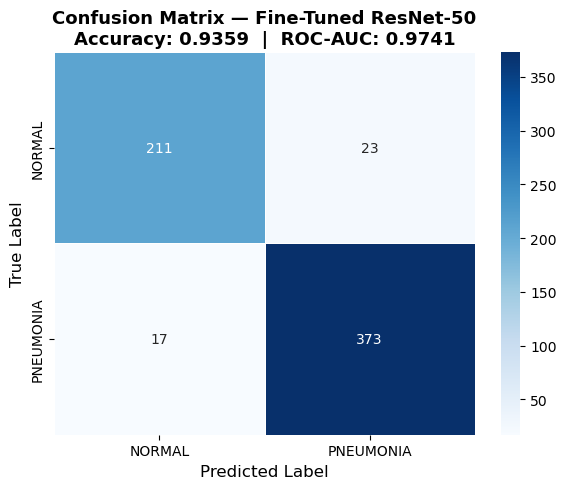

💾 Confusion matrix saved: confusion_matrix.png

  Clinical Metrics:
  Sensitivity (Recall for PNEUMONIA) : 0.9564
  Specificity (Recall for NORMAL)    : 0.9017
  False Negatives (missed cases)     : 17
  False Positives (false alarms)     : 23


In [11]:
# ============================================================
# CELL 8 — Comprehensive Test Set Evaluation
# ============================================================

model.eval()  # Disable Dropout + fix BatchNorm statistics

all_preds  = []  # Predicted class indices
all_labels = []  # True class indices
all_probs  = []  # Predicted probabilities (for ROC-AUC)

with torch.no_grad():  # No gradient computation needed for inference
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)

        outputs     = model(inputs)                          # Forward pass
        probs       = torch.softmax(outputs, dim=1)          # Convert to probabilities
        _, preds    = torch.max(probs, 1)                    # Predicted class

        all_preds .extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs .extend(probs[:, 1].cpu().numpy())         # P(Pneumonia)

# ── Compute metrics ──────────────────────────────────────────
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = (all_preds == all_labels).mean()
roc_auc  = roc_auc_score(all_labels, all_probs)

print("=" * 55)
print("  TEST SET EVALUATION RESULTS")
print("=" * 55)
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  ROC-AUC Score : {roc_auc:.4f}")
print()
print("  Classification Report:")
print("  " + "-" * 50)
print(classification_report(
    all_labels,
    all_preds,
    target_names = CONFIG['class_names']
))

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CONFIG['class_names'],
    yticklabels=CONFIG['class_names'],
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title(
    f'Confusion Matrix — Fine-Tuned ResNet-50\n'
    f'Accuracy: {test_acc:.4f}  |  ROC-AUC: {roc_auc:.4f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Confusion matrix saved: confusion_matrix.png")

# ── Clinical interpretation ───────────────────────────────────
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall for Pneumonia (most important!)
specificity = tn / (tn + fp)  # True Negative Rate
print(f"\n  Clinical Metrics:")
print(f"  Sensitivity (Recall for PNEUMONIA) : {sensitivity:.4f}")
print(f"  Specificity (Recall for NORMAL)    : {specificity:.4f}")
print(f"  False Negatives (missed cases)     : {fn}")
print(f"  False Positives (false alarms)     : {fp}")


---
## Cell 9 — Training Curves Visualization

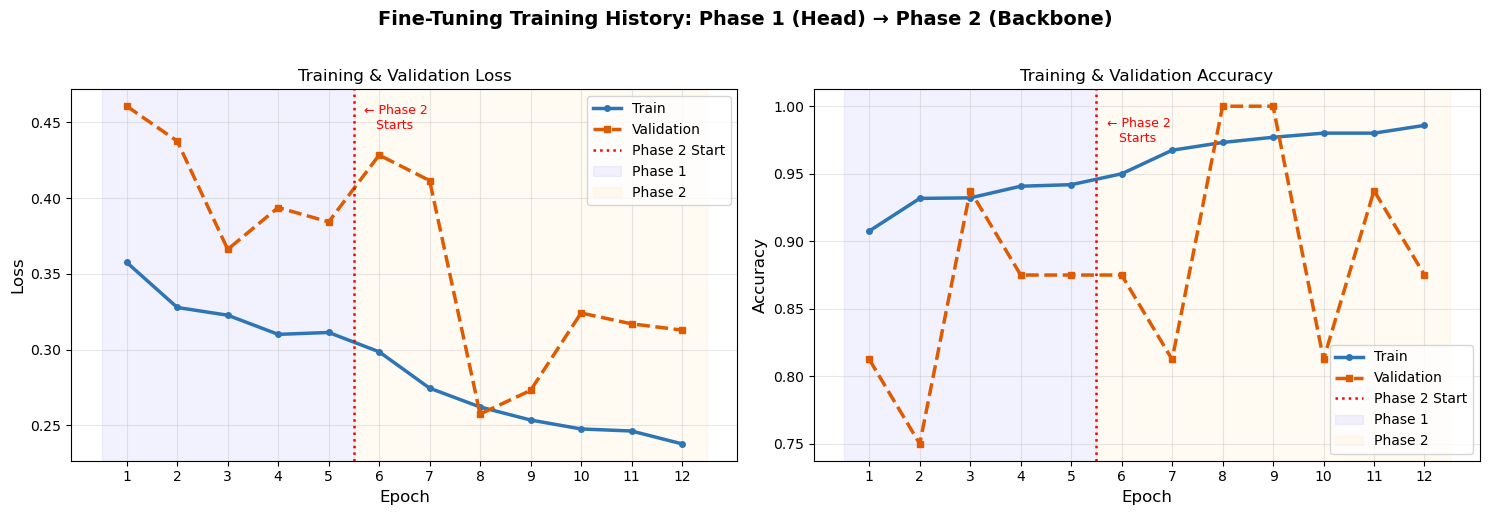

💾 Training curves saved: training_curves.png

📊 Summary:
   Phase 1 epochs ran : 5
   Phase 2 epochs ran : 7
   Best Val Accuracy  : 1.0000 (epoch 8)
   Final Test Accuracy: 0.9359
   Final ROC-AUC      : 0.9741


In [12]:
# ============================================================
# CELL 9 — Training History Visualization
# ============================================================

# ── Merge Phase 1 and Phase 2 histories ──────────────────────
full_history = {
    key: history_p1[key] + history_p2[key]
    for key in history_p1
}
p1_len  = len(history_p1['train_loss'])  # Where Phase 2 starts
epochs  = list(range(1, len(full_history['train_loss']) + 1))

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    'Fine-Tuning Training History: Phase 1 (Head) → Phase 2 (Backbone)',
    fontsize=14, fontweight='bold', y=1.02
)

COLORS = {'train': '#2E75B6', 'val': '#E05A00'}

for idx, (metric, ylabel) in enumerate([('loss', 'Loss'), ('acc', 'Accuracy')]):
    ax = axes[idx]

    # Plot train and val curves
    ax.plot(epochs, full_history[f'train_{metric}'],
            color=COLORS['train'], lw=2.5, marker='o', ms=4,
            label='Train')
    ax.plot(epochs, full_history[f'val_{metric}'],
            color=COLORS['val'],   lw=2.5, marker='s', ms=4,
            linestyle='--', label='Validation')

    # Mark Phase 2 start with a vertical line
    ax.axvline(x=p1_len + 0.5, color='red', lw=1.8, linestyle=':',
               label='Phase 2 Start')
    ax.text(p1_len + 0.7, ax.get_ylim()[1] * 0.98,
            '← Phase 2\n   Starts',
            fontsize=9, color='red', va='top')

    # Shade Phase 1 and Phase 2 regions
    ax.axvspan(0.5, p1_len + 0.5,   alpha=0.05, color='blue',  label='Phase 1')
    ax.axvspan(p1_len + 0.5,
               len(epochs) + 0.5, alpha=0.05, color='orange', label='Phase 2')

    ax.set_xlabel('Epoch',  fontsize=12)
    ax.set_ylabel(ylabel,   fontsize=12)
    ax.set_title(f'Training & Validation {ylabel}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xticks(epochs)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Training curves saved: training_curves.png")

# ── Print final best values ───────────────────────────────────
best_val_acc  = max(full_history['val_acc'])
best_epoch    = full_history['val_acc'].index(best_val_acc) + 1
print(f"\n📊 Summary:")
print(f"   Phase 1 epochs ran : {p1_len}")
print(f"   Phase 2 epochs ran : {len(epochs) - p1_len}")
print(f"   Best Val Accuracy  : {best_val_acc:.4f} (epoch {best_epoch})")
print(f"   Final Test Accuracy: {test_acc:.4f}")
print(f"   Final ROC-AUC      : {roc_auc:.4f}")
